<a href="https://colab.research.google.com/github/rodrigologin0-cpu/Rodrigo-de-Souza-Lima/blob/main/Narx_Otimiza%C3%A7%C3%A3o_AG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# NARX POLINOMIAL + LASSO + ALGORITMO GENÉTICO
# Seleção automática de termos para modelo implementável em PLC
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from google.colab import files
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# ============================================================
# 1. Upload do arquivo
# ============================================================

print("Faça upload do arquivo Excel (.xlsx)")
uploaded = files.upload()

arquivo = list(uploaded.keys())[0]
df = pd.read_excel(arquivo)

print("\nColunas disponíveis:")
for col in df.columns:
    print("-", col)


Faça upload do arquivo Excel (.xlsx)


Saving Temperatura.xlsx to Temperatura.xlsx

Colunas disponíveis:
- TEMP
- VAZÃO
- POTÊNCIA
- VALVULA
- TEMP_1
- TEMP_2


In [5]:
# ============================================================
# 2. Configurações do usuário
# ============================================================

col_y = input("\nDigite o nome da variável de saída Y: ")

n_inputs = int(input("Quantas entradas exógenas deseja usar? "))

cols_u = []
for i in range(n_inputs):
    col = input(f"Digite o nome da entrada U{i+1}: ")
    cols_u.append(col)

horizonte = int(input("Horizonte de previsão em passos. Exemplo 1, 5, 10: "))

n_lags_y = int(input("Número de atrasos da saída Y. Exemplo 3: "))
n_lags_u = int(input("Número de atrasos das entradas U. Exemplo 2: "))

grau_polinomio = int(input("Grau do polinômio. Recomendo 1 ou 2: "))

usar_amostra = input("Usar apenas uma amostra dos dados para acelerar? (s/n): ").lower() == "s"

if usar_amostra:
    n_amostras = int(input("Quantas amostras usar? Exemplo 20000: "))
    df = df.iloc[:n_amostras].copy()



Digite o nome da variável de saída Y: TEMP
Quantas entradas exógenas deseja usar? 5
Digite o nome da entrada U1: VAZÃO
Digite o nome da entrada U2: POTÊNCIA
Digite o nome da entrada U3: VALVULA
Digite o nome da entrada U4: TEMP_1
Digite o nome da entrada U5: TEMP_2
Horizonte de previsão em passos. Exemplo 1, 5, 10: 1
Número de atrasos da saída Y. Exemplo 3: 3
Número de atrasos das entradas U. Exemplo 2: 2
Grau do polinômio. Recomendo 1 ou 2: 1
Usar apenas uma amostra dos dados para acelerar? (s/n): n


In [6]:
# ============================================================
# 3. Criação da base NARX
# ============================================================

data = pd.DataFrame(index=df.index)

# atrasos da saída
for lag in range(1, n_lags_y + 1):
    data[f"{col_y}_t-{lag}"] = df[col_y].shift(lag)

# atrasos das entradas
for col in cols_u:
    for lag in range(1, n_lags_u + 1):
        data[f"{col}_t-{lag}"] = df[col].shift(lag)

# alvo futuro
data[f"{col_y}_target_t+{horizonte}"] = df[col_y].shift(-horizonte)

data = data.dropna().reset_index(drop=True)

X_base = data.drop(columns=[f"{col_y}_target_t+{horizonte}"])
y = data[f"{col_y}_target_t+{horizonte}"].values

print("\nEntradas NARX criadas:")
for c in X_base.columns:
    print("-", c)



Entradas NARX criadas:
- TEMP_t-1
- TEMP_t-2
- TEMP_t-3
- VAZÃO_t-1
- VAZÃO_t-2
- POTÊNCIA_t-1
- POTÊNCIA_t-2
- VALVULA_t-1
- VALVULA_t-2
- TEMP_1_t-1
- TEMP_1_t-2
- TEMP_2_t-1
- TEMP_2_t-2


In [7]:
# ============================================================
# 4. Separação temporal treino/teste
# ============================================================

train_size = int(len(X_base) * 0.8)

X_train_base = X_base.iloc[:train_size]
X_test_base  = X_base.iloc[train_size:]

y_train = y[:train_size]
y_test  = y[train_size:]


In [8]:
# ============================================================
# 5. Normalização + Polinômio
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_base)
X_test_scaled  = scaler.transform(X_test_base)

poly = PolynomialFeatures(
    degree=grau_polinomio,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly  = poly.transform(X_test_scaled)

feature_names = poly.get_feature_names_out(X_base.columns)

print(f"\nNúmero total de termos polinomiais: {len(feature_names)}")



Número total de termos polinomiais: 13


In [9]:
# ============================================================
# 6. Função de avaliação
# ============================================================

def avaliar_modelo(Xtr, Xte, ytr, yte, nome="Modelo"):
    modelo = LinearRegression()
    modelo.fit(Xtr, ytr)

    pred_train = modelo.predict(Xtr)
    pred_test = modelo.predict(Xte)

    mae_train = mean_absolute_error(ytr, pred_train)
    rmse_train = np.sqrt(mean_squared_error(ytr, pred_train))
    r2_train = r2_score(ytr, pred_train)

    mae_test = mean_absolute_error(yte, pred_test)
    rmse_test = np.sqrt(mean_squared_error(yte, pred_test))
    r2_test = r2_score(yte, pred_test)

    return {
        "nome": nome,
        "modelo": modelo,
        "pred_test": pred_test,
        "mae_train": mae_train,
        "rmse_train": rmse_train,
        "r2_train": r2_train,
        "mae_test": mae_test,
        "rmse_test": rmse_test,
        "r2_test": r2_test,
        "n_termos": Xtr.shape[1]
    }


In [10]:
# ============================================================
# 7. Modelo base com todos os termos
# ============================================================

resultado_base = avaliar_modelo(
    X_train_poly,
    X_test_poly,
    y_train,
    y_test,
    nome="Todos os termos"
)

print("\nModelo base:")
print(f"MAE teste  = {resultado_base['mae_test']:.5f}")
print(f"RMSE teste = {resultado_base['rmse_test']:.5f}")
print(f"R² teste   = {resultado_base['r2_test']:.5f}")
print(f"N termos   = {resultado_base['n_termos']}")



Modelo base:
MAE teste  = 0.09204
RMSE teste = 0.11583
R² teste   = 0.99996
N termos   = 13


In [11]:
# ============================================================
# 8. Seleção automática por LASSO
# ============================================================

print("\nRodando Lasso para seleção automática de termos...")

alphas_lasso = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0]

resultados_lasso = []

for alpha in alphas_lasso:
    lasso = Lasso(alpha=alpha, max_iter=30000)
    lasso.fit(X_train_poly, y_train)

    mask = np.abs(lasso.coef_) > 1e-8
    n_sel = np.sum(mask)

    if n_sel == 0:
        continue

    Xtr_sel = X_train_poly[:, mask]
    Xte_sel = X_test_poly[:, mask]

    r = avaliar_modelo(
        Xtr_sel,
        Xte_sel,
        y_train,
        y_test,
        nome=f"Lasso alpha={alpha}"
    )

    score = r["mae_test"] * (1 + 0.002 * r["n_termos"])

    resultados_lasso.append({
        "alpha": alpha,
        "mask": mask,
        "resultado": r,
        "score": score
    })

melhor_lasso = min(resultados_lasso, key=lambda x: x["score"])

print("\nMelhor Lasso:")
print(f"Alpha      = {melhor_lasso['alpha']}")
print(f"MAE teste  = {melhor_lasso['resultado']['mae_test']:.5f}")
print(f"RMSE teste = {melhor_lasso['resultado']['rmse_test']:.5f}")
print(f"R² teste   = {melhor_lasso['resultado']['r2_test']:.5f}")
print(f"N termos   = {melhor_lasso['resultado']['n_termos']}")



Rodando Lasso para seleção automática de termos...

Melhor Lasso:
Alpha      = 0.0001
MAE teste  = 0.09204
RMSE teste = 0.11583
R² teste   = 0.99996
N termos   = 13


In [12]:
# ============================================================
# 9. Algoritmo Genético para seleção de termos
# ============================================================

print("\nRodando Algoritmo Genético para seleção de termos...")

n_features = X_train_poly.shape[1]

pop_size = int(input("Tamanho da população GA. Exemplo 30: "))
n_generations = int(input("Número de gerações GA. Exemplo 30: "))
mutation_rate = float(input("Taxa de mutação. Exemplo 0.05: "))
max_terms = int(input("Número máximo de termos permitidos. Exemplo 10: "))

def criar_individuo(n_features, max_terms):
    ind = np.zeros(n_features, dtype=bool)
    n = random.randint(1, max_terms)
    idx = random.sample(range(n_features), n)
    ind[idx] = True
    return ind

def fitness(ind):
    n_terms = np.sum(ind)

    if n_terms == 0:
        return 1e9, None

    if n_terms > max_terms:
        return 1e9, None

    Xtr = X_train_poly[:, ind]
    Xte = X_test_poly[:, ind]

    try:
        r = avaliar_modelo(Xtr, Xte, y_train, y_test)
        score = r["mae_test"] * (1 + 0.005 * n_terms)
        return score, r

    except:
        return 1e9, None

def crossover(p1, p2):
    point = random.randint(1, n_features - 2)
    child = np.concatenate([p1[:point], p2[point:]])
    return child.astype(bool)

def mutate(ind, mutation_rate):
    for i in range(len(ind)):
        if random.random() < mutation_rate:
            ind[i] = not ind[i]

    # garante pelo menos 1 termo
    if np.sum(ind) == 0:
        ind[random.randint(0, len(ind)-1)] = True

    # se exceder max_terms, remove aleatoriamente
    while np.sum(ind) > max_terms:
        idx_true = np.where(ind)[0]
        ind[random.choice(idx_true)] = False

    return ind

# população inicial
population = [criar_individuo(n_features, max_terms) for _ in range(pop_size)]

best_ind = None
best_score = 1e9
best_result = None

historico = []

for gen in range(n_generations):
    scored = []

    for ind in population:
        score, r = fitness(ind)
        scored.append((score, ind, r))

    scored.sort(key=lambda x: x[0])

    if scored[0][0] < best_score:
        best_score = scored[0][0]
        best_ind = scored[0][1].copy()
        best_result = scored[0][2]

    historico.append(best_score)

    # elitismo
    elite_count = max(2, pop_size // 5)
    new_population = [scored[i][1].copy() for i in range(elite_count)]

    # reprodução
    while len(new_population) < pop_size:
        p1 = random.choice(scored[:pop_size//2])[1]
        p2 = random.choice(scored[:pop_size//2])[1]

        child = crossover(p1, p2)
        child = mutate(child, mutation_rate)

        new_population.append(child)

    population = new_population

    print(f"Geração {gen+1}/{n_generations} | Melhor score = {best_score:.5f}")

print("\nMelhor GA:")
print(f"MAE teste  = {best_result['mae_test']:.5f}")
print(f"RMSE teste = {best_result['rmse_test']:.5f}")
print(f"R² teste   = {best_result['r2_test']:.5f}")
print(f"N termos   = {best_result['n_termos']}")



Rodando Algoritmo Genético para seleção de termos...
Tamanho da população GA. Exemplo 30: 30
Número de gerações GA. Exemplo 30: 30
Taxa de mutação. Exemplo 0.05: 0.05
Número máximo de termos permitidos. Exemplo 10: 10
Geração 1/30 | Melhor score = 0.09554
Geração 2/30 | Melhor score = 0.09485
Geração 3/30 | Melhor score = 0.09462
Geração 4/30 | Melhor score = 0.09433
Geração 5/30 | Melhor score = 0.09433
Geração 6/30 | Melhor score = 0.09433
Geração 7/30 | Melhor score = 0.09433
Geração 8/30 | Melhor score = 0.09433
Geração 9/30 | Melhor score = 0.09433
Geração 10/30 | Melhor score = 0.09403
Geração 11/30 | Melhor score = 0.09403
Geração 12/30 | Melhor score = 0.09403
Geração 13/30 | Melhor score = 0.09403
Geração 14/30 | Melhor score = 0.09403
Geração 15/30 | Melhor score = 0.09403
Geração 16/30 | Melhor score = 0.09403
Geração 17/30 | Melhor score = 0.09403
Geração 18/30 | Melhor score = 0.09403
Geração 19/30 | Melhor score = 0.09403
Geração 20/30 | Melhor score = 0.09403
Geração 21

In [13]:
# ============================================================
# 10. Comparativo final
# ============================================================

comparativo = pd.DataFrame([
    {
        "Método": "Todos os termos",
        "N termos": resultado_base["n_termos"],
        "MAE teste": resultado_base["mae_test"],
        "RMSE teste": resultado_base["rmse_test"],
        "R2 teste": resultado_base["r2_test"]
    },
    {
        "Método": "Lasso + Regressão",
        "N termos": melhor_lasso["resultado"]["n_termos"],
        "MAE teste": melhor_lasso["resultado"]["mae_test"],
        "RMSE teste": melhor_lasso["resultado"]["rmse_test"],
        "R2 teste": melhor_lasso["resultado"]["r2_test"]
    },
    {
        "Método": "Algoritmo Genético",
        "N termos": best_result["n_termos"],
        "MAE teste": best_result["mae_test"],
        "RMSE teste": best_result["rmse_test"],
        "R2 teste": best_result["r2_test"]
    }
])

print("\nComparativo final:")
display(comparativo)


Comparativo final:


,Método,N termos,MAE teste,RMSE teste,R2 teste
0,Todos os termos,13,0.092035,0.115833,0.999955
1,Lasso + Regressão,13,0.092035,0.115833,0.999955
2,Algoritmo Genético,3,0.092644,0.116944,0.999954



Quantas amostras mostrar no gráfico? Exemplo 1000: 100


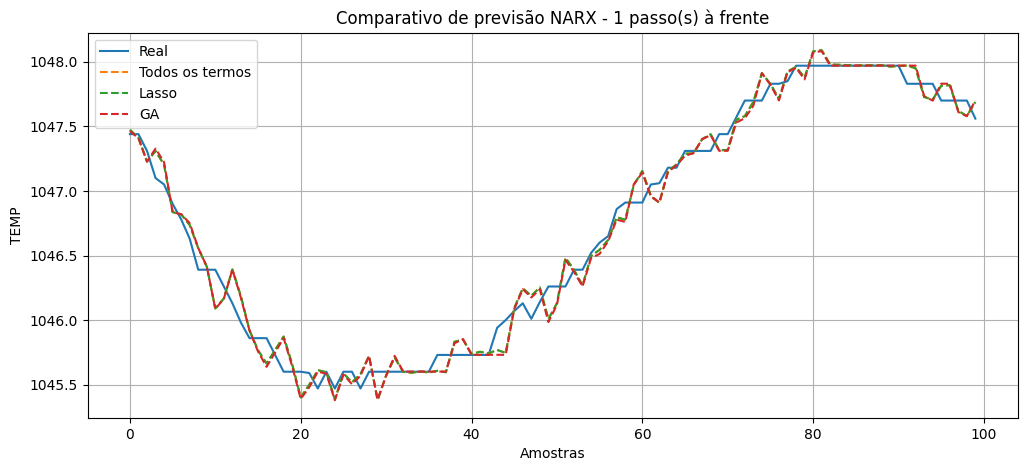

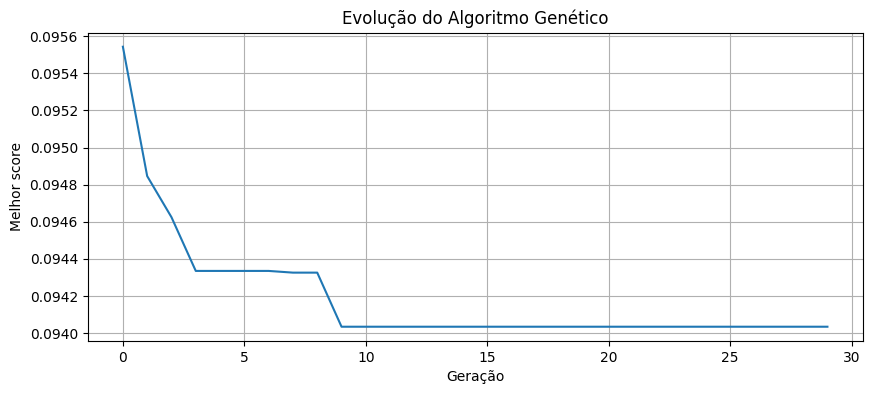

In [15]:
# ============================================================
# 11. Gráficos
# ============================================================

n_plot = int(input("\nQuantas amostras mostrar no gráfico? Exemplo 1000: "))

plt.figure(figsize=(12,5))
plt.plot(y_test[:n_plot], label="Real")
plt.plot(resultado_base["pred_test"][:n_plot], linestyle="--", label="Todos os termos")
plt.plot(melhor_lasso["resultado"]["pred_test"][:n_plot], linestyle="--", label="Lasso")
plt.plot(best_result["pred_test"][:n_plot], linestyle="--", label="GA")
plt.title(f"Comparativo de previsão NARX - {horizonte} passo(s) à frente")
plt.xlabel("Amostras")
plt.ylabel(col_y)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(historico)
plt.title("Evolução do Algoritmo Genético")
plt.xlabel("Geração")
plt.ylabel("Melhor score")
plt.grid(True)
plt.show()


In [16]:
# ============================================================
# 12. Exportar coeficientes
# ============================================================

def exportar_coeficientes(nome, mask, resultado):
    termos = feature_names[mask]
    coef = resultado["modelo"].coef_

    df_coef = pd.DataFrame({
        "Termo": termos,
        "Coeficiente": coef
    })

    df_coef.loc[len(df_coef)] = ["Bias", resultado["modelo"].intercept_]

    arquivo = f"coeficientes_{nome}.xlsx"
    df_coef.to_excel(arquivo, index=False)
    files.download(arquivo)

# máscaras
mask_all = np.ones(n_features, dtype=bool)
mask_lasso = melhor_lasso["mask"]
mask_ga = best_ind

comparativo.to_excel("comparativo_narx_lasso_ga.xlsx", index=False)
files.download("comparativo_narx_lasso_ga.xlsx")

exportar_coeficientes("todos_termos", mask_all, resultado_base)
exportar_coeficientes("lasso", mask_lasso, melhor_lasso["resultado"])
exportar_coeficientes("genetico", mask_ga, best_result)

print("\nArquivos exportados:")
print("- comparativo_narx_lasso_ga.xlsx")
print("- coeficientes_todos_termos.xlsx")
print("- coeficientes_lasso.xlsx")
print("- coeficientes_genetico.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Arquivos exportados:
- comparativo_narx_lasso_ga.xlsx
- coeficientes_todos_termos.xlsx
- coeficientes_lasso.xlsx
- coeficientes_genetico.xlsx
